# Theoretical probability of error for QPSK modulation

Let us analyse theoretical probability of error for QPSK modulation. First let us install all dependencies.

In [1]:
pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


Import them

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

Quick and dirty piece of code that computes QPSK probability of error and compares it with theoretical one

Processing Es/N0 = 0dB
Es/N0 = 0dB, number_of_errors = 146211, results = 0.29
Processing Es/N0 = 1dB
Es/N0 = 1dB, number_of_errors = 122439, results = 0.24
Processing Es/N0 = 2dB
Es/N0 = 2dB, number_of_errors = 98255, results = 0.20
Processing Es/N0 = 3dB
Es/N0 = 3dB, number_of_errors = 76047, results = 0.15
Processing Es/N0 = 4dB
Es/N0 = 4dB, number_of_errors = 54904, results = 0.11
Processing Es/N0 = 5dB
Es/N0 = 5dB, number_of_errors = 36934, results = 0.07
Processing Es/N0 = 6dB
Es/N0 = 6dB, number_of_errors = 22596, results = 0.05
Processing Es/N0 = 7dB
Es/N0 = 7dB, number_of_errors = 12634, results = 0.03
Processing Es/N0 = 8dB
Es/N0 = 8dB, number_of_errors = 5885, results = 0.01
Processing Es/N0 = 9dB
Es/N0 = 9dB, number_of_errors = 2353, results = 0.00


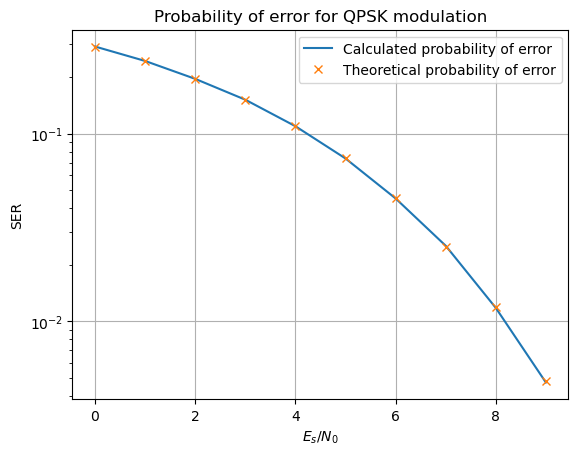

In [3]:
esno_min = 0
esno_max = 10
esno_step = 1
number_of_iterations = 500_000

actual_results = {}
theoretical_results = {}
for esno in range(esno_min, esno_max, esno_step):
    print(f"Processing Es/N0 = {esno}dB")
    # Convert SNR to linear scale
    esno_linear = 10 ** (esno / 10)
    number_of_errors = 0
    for idx in range(number_of_iterations):
        # Generate QPSK symbol and normalise it
        re_x = np.random.randint(0, 2) * 2 - 1
        im_x = np.random.randint(0, 2) * 2 - 1
        x = 1 / np.sqrt(2) * (re_x + 1.0j * im_x)
        # Generate noise
        sigma = 1 / np.sqrt(2 * esno_linear)
        noise = sigma * np.random.randn() + 1.0j * sigma * np.random.randn()
        y = x + noise
        # Count number of errors
        number_of_errors += np.sign(np.real(y)) != np.sign(np.real(x)) or np.sign(np.imag(y)) != np.sign(np.imag(x))
    actual_results[esno] = number_of_errors / number_of_iterations
    p = 0.5 * erfc(np.sqrt(esno_linear / 2))
    theoretical_results[esno] = 1 - (1 - p) ** 2
    print(f"Es/N0 = {esno}dB, number_of_errors = {number_of_errors}, results = {actual_results[esno]:.2f}")

# Plot results
plt.figure()
plt.semilogy(actual_results.keys(), actual_results.values(), label = 'Calculated probability of error')
plt.semilogy(theoretical_results.keys(), theoretical_results.values(), 'x', label = 'Theoretical probability of error')
plt.xlabel('$E_{s}/N_{0}$')
plt.ylabel('SER')
plt.title('Probability of error for QPSK modulation')
plt.legend()
plt.grid()
plt.show()